# Penguins - Application of Data Visualisation

In [45]:
# Standard imports for EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Load the dataset
df = pd.read_csv("Code files/penguins_size.csv")

# Preview the first few rows
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [47]:
# Dataset shape and data types
print("Shape:", df.shape)
print()
print(df.info())

Shape: (344, 7)

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB
None


First look at the dataset shows:
- The dataset contains 344 rows and 7 columns. 
- Four columns hold numerical measurements: culmen length, culmen depth, flipper length, and body mass.
- Three columns are categorical: species, island, and sex.

In [48]:
# Unique species and islands in the dataset
print("Species:", df_clean["species"].unique())
print("Islands:", df_clean["island"].unique())

Species: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str
Islands: <StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str


- There are 3 species of penguin in the dataset: Adelie, Chinstrap and Gentoo.
- 3 islands penguins were sampled: Torgersen, Biscoe and Dream island.

In [49]:
# Count missing values per column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


The missing values check shows that two rows have no physical measurements recorded at all, and ten rows have no sex recorded.
A row with no measurements cannot contribute to any part of the analysis, so those two rows will be dropped during data cleaning. 
However, the ten rows missing sex can be kept because their physical measurements are complete and still useful for size and shape comparisons.

## Data cleaning

In [50]:
# Drop rows where physical measurements are missing
df_clean = df.dropna(subset=[
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
])

# Confirm the result
print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(df_clean))
print("Missing values remaining:")
print(df_clean.isnull().sum())

Rows before cleaning: 344
Rows after cleaning: 342
Missing values remaining:
species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  8
dtype: int64


After cleaning, 342 rows remained for analysis.

## Preprocessing

In [51]:
# Summary statistics for numerical columns
df_clean.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Initial look at summary stats shows:
- There is a wide range in body mass of penguins, from 2,700g to 6,300g, suggesting there could be a meaningful size differences between species.
- Flipper length ranges from 172mm to 231mm. 
- The average penguin in this dataset weighs around 4,202g with an average flipper length of about 201mm.

In [52]:
# Count of each species and island
print("Species counts:")
print(df_clean["species"].value_counts())
print()
print("Island counts:")
print(df_clean["island"].value_counts())

Species counts:
species
Adelie       151
Gentoo       123
Chinstrap     68
Name: count, dtype: int64

Island counts:
island
Biscoe       167
Dream        124
Torgersen     51
Name: count, dtype: int64


- Adelie is the most common species with 151 individuals, followed by Gentoo with 123 and Chinstrap with 68. 
- Biscoe Island has the highest number of penguins sampled (167), followed by Dream (124) and Torgersen (51). 

**NOTE:** These differences in count hint at uneven species distribution across islands, which the charts below explore further.

## Exploratory Data Analysis

### 1) Penguin count by Species

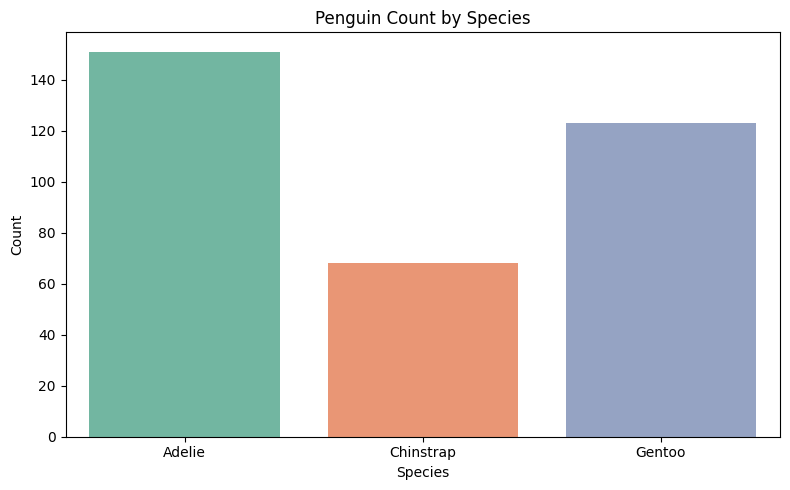

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="species",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Penguin Count by Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Charts/chart1_species_count.png", dpi=150)
plt.show()

Adelie is the most common species in the dataset with 151 individuals, almost double the number of Chinstrap penguins (68). 
Gentoo sits in the middle at 123. 

**Note:** This uneven distribution is worth keeping in mind when comparing species, as conclusions drawn about Chinstrap are based
on a smaller sample size.

### 2) Species distribution across Islands

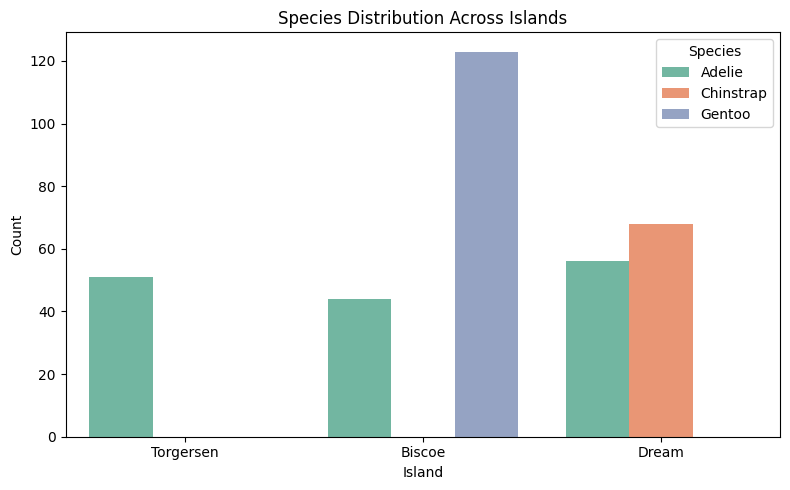

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x="island",
    hue="species",
    palette="Set2"
)
plt.title("Species Distribution Across Islands")
plt.xlabel("Island")
plt.ylabel("Count")
plt.legend(title="Species")
plt.tight_layout()
plt.savefig("Charts/chart2_species_island.png", dpi=150)
plt.show()

Each species shows a preference for island:
- Gentoo penguins are found almost entirely on Biscoe Island, while Chinstrap penguins appear only on Dream Island. 
- Adelie is the only species present on all three islands, making it the most widely distributed of the three. 
- Torgersen Island is home exclusively to Adelie penguins. 

Overall, this pattern suggests the species occupy distinct geographical locations or niches within the Palmer Archipelago.

### 3) Body mass distribution by Species

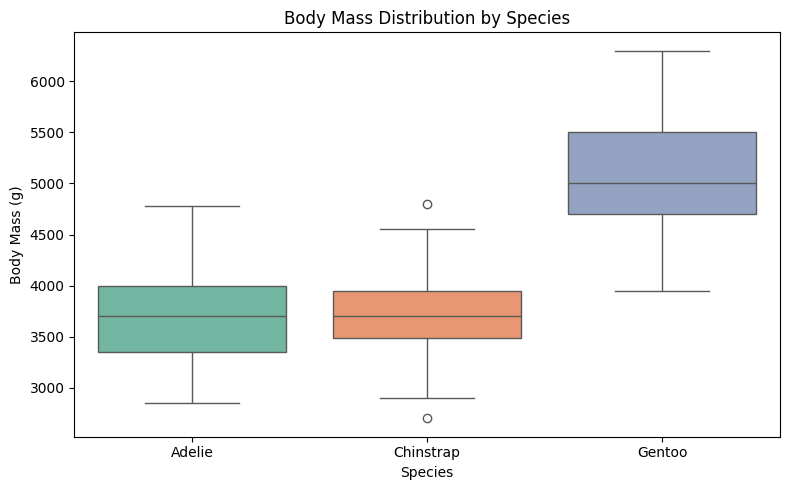

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="species",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Body Mass Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Body Mass (g)")
plt.tight_layout()
plt.savefig("Charts/chart3_body_mass.png", dpi=150)
plt.show()

There are size differences between penguin species:
- Gentoo penguins are considerably heavier than the other two species, with a median body mass of around 5,000g. 
- Adelie and Chinstrap are similar in weight, both centred around 3,700g. 
- Chinstrap shows two outliers, indicating a small number of individuals that are unusually light or heavy for the species. 
- The separation between Gentoo and the other two species is clear and consistent.

### 4) Flipper length distribution by Species

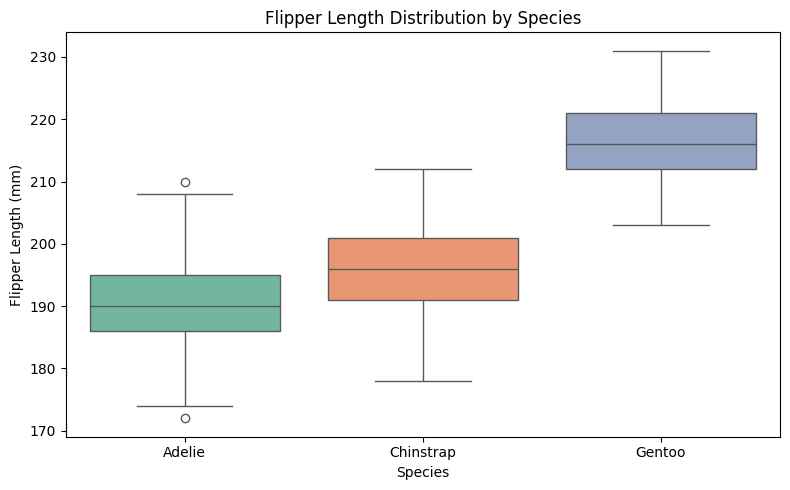

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_clean,
    x="species",
    y="flipper_length_mm",
    hue="species",
    palette="Set2",
    legend=False
)
plt.title("Flipper Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Flipper Length (mm)")
plt.tight_layout()
plt.savefig("Charts/chart4_flipper_length.png", dpi=150)
plt.show()

There are disctinct differences in flipper length between penguin species:
- Gentoo penguins have the longest flippers with a median of around 216mm, consistent with their larger body size. 
- Adelie penguins have the shortest flippers at around 190mm, while Chinstrap sits between the two at roughly 196mm. 

The pattern mirrors the body mass results, suggesting that Gentoo is physically larger across all measurements.

### 5) Flipper length vs Body mass by Species

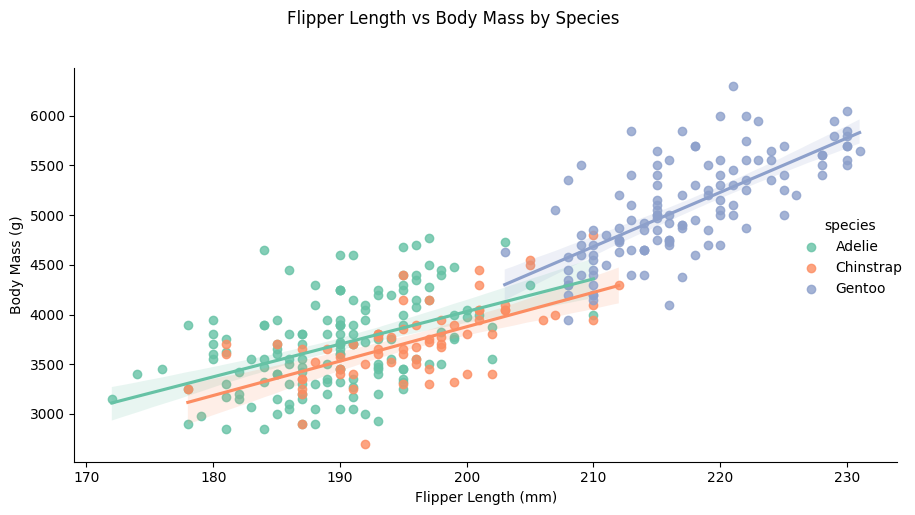

In [57]:
g = sns.lmplot(
    data=df_clean,
    x="flipper_length_mm",
    y="body_mass_g",
    hue="species",
    palette="Set2",
    height=5,
    aspect=1.6
)
g.set_axis_labels("Flipper Length (mm)", "Body Mass (g)")
g.figure.suptitle(
    "Flipper Length vs Body Mass by Species",
    y=1.02
)
plt.tight_layout()
plt.savefig("Charts/chart5_flipper_vs_mass.png", dpi=150)
plt.show()

There is a strong positive relationship between flipper length and body mass across all three species:
- Larger flippers correspond to heavier penguins in each case. 
- Gentoo penguins form a distinct cluster in the upper right of the plot, with longer flippers and higher body mass than the other two species. 
- Adelie and Chinstrap overlap considerably, though Chinstrap tends to sit slightly higher for a given flipper length, suggesting a marginally denser build relative to flipper size.

### 6) Correlation between measurement variables

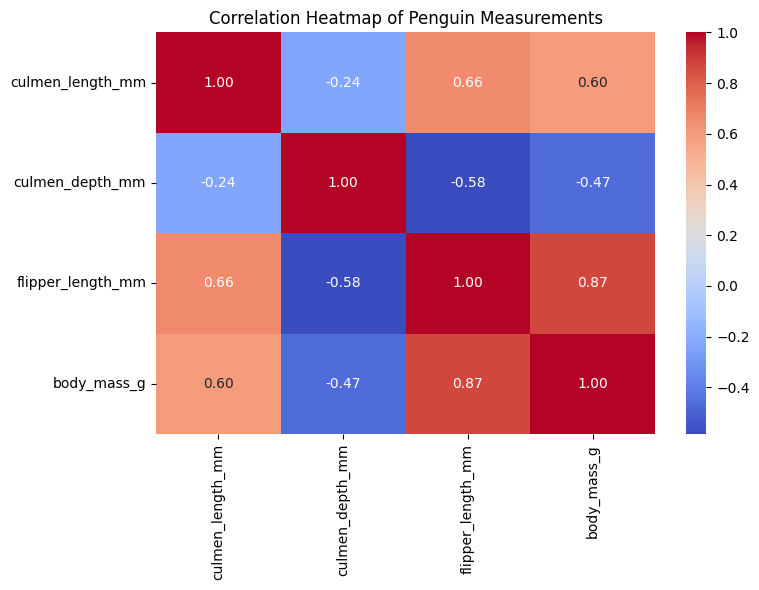

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_clean[
        [
            "culmen_length_mm",
            "culmen_depth_mm",
            "flipper_length_mm",
            "body_mass_g"
        ]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Penguin Measurements")
plt.tight_layout()
plt.savefig("Charts/chart6_correlation_heatmap.png", dpi=150)
plt.show()

Correlation between measurements:
- **Flipper length** and **body mass** have the strongest positive correlation at 0.87, confirming that larger penguins have proportionally longer flippers. 
- **Culmen length** also correlates positively with both **flipper length** (0.66) and **body mass** (0.60), suggesting that beak length grows in line with overall body size.

However, **Culmen depth** tells a different story:
- It correlates negatively with **flipper length** (-0.58) and **body mass** (-0.47), meaning penguins with deeper beaks tend to be smaller overall. 

Overall, this pattern is driven by species differences:
- Adelie penguins have the deepest beaks relative to their size but are the smallest species in the dataset. 
- The negative correlations reflect that species-level difference rather than a within-species trend.

## Summary of Findings

The analysis of the Palmer Penguins dataset reveals clear physical and geographical differences between the three species.

**Species distribution:** Adelie is the most numerous species (151), followed by Gentoo (123) and Chinstrap (68).

**Island habitat:** Each species has a strong island preference. Gentoo penguins are found almost exclusively on Biscoe Island, Chinstrap penguins are concentrated on Dream Island, and Torgersen Island is home only to Adelie penguins.

**Body size:** Gentoo penguins are notably larger than the other two species, with a median body mass of around 5,000g compared to roughly 3,700g for both Adelie and Chinstrap.

**Flipper length:** Gentoo penguins have the longest flippers, consistent with their larger body size. Adelie penguins have the shortest flippers despite being the most numerous species. The scatter plot confirms this visually, with each species forming a distinct cluster and all three showing a consistent upward trend between flipper length and body mass.

**Correlations:** Flipper length and body mass show the strongest positive correlation (0.87), confirming that larger penguins have proportionally longer flippers. Culmen depth shows a negative correlation with both flipper length (-0.58) and body mass (-0.47). This pattern reflects that Adelie penguins, which have the deepest beaks, are also the smallest species.